In [2]:
!pip install gazpacho

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for gazpacho: filename=gazpacho-1.1-py3-none-any.whl size=7522 sha256=c99a209be535deeba521c111c04ce7d6a60d51ef2c3a10231db70a880c9b7d96
  Stored in directory: /root/.cache/pip/wheels/2b/49/33/b889bdad7e58b8a514eb3a47869eadb9ef67bd59a534b5e24d
Successfully built gazpacho


In [7]:
# import library
import requests
import gazpacho as gz

# skooldio medium website
url = "https://en.wikipedia.org/wiki/Pareto_principle"

# Add a User-Agent header to mimic a web browser
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

# request content from medium with headers
response = requests.get(url, headers=headers)
print(response.status_code)

# transform to Soup object
web = gz.Soup(response.text)

# find the element you want
display(web.find("h1"))
display(web.find("h2"))
display(web.find("h3"))

200


<h1 id="firstHeading" class="firstHeading mw-first-heading">
  <span class="mw-page-title-main">Pareto principle</span>
</h1>

[<h2 class="vector-pinnable-header-label">Contents</h2>,
 <h2 id="History">History</h2>,
 <h2 id="Mathematical_explanation">Mathematical explanation</h2>,
 <h2 id="Analysis">Analysis</h2>,
 <h2 id="Applications">Applications</h2>,
 <h2 id="See_also">See also</h2>,
 <h2 id="References">References</h2>,
 <h2 id="Further_reading">Further reading</h2>,
 <h2 id="External_links">External links</h2>]

[<h3 id="Derivation_of_α_for_the_80:20_rule">
   <span id="Derivation_of_.CE.B1_for_the_80:20_rule"/>
   Derivation of 
   <i>α</i>
    for the 80:20 rule
 </h3>,
 <h3 id="Gini_coefficient_and_Hoover_index">Gini coefficient and Hoover index</h3>,
 <h3 id="Economics">Economics</h3>,
 <h3 id="Computing">Computing</h3>,
 <h3 id="Occupational_health_and_safety">Occupational health and safety</h3>,
 <h3 id="Engineering_and_quality_control">Engineering and quality control</h3>,
 <h3 id="Health_and_social_outcomes">Health and social outcomes</h3>]

# Scraping Product & Price

### Cython.io - Raspberry pi

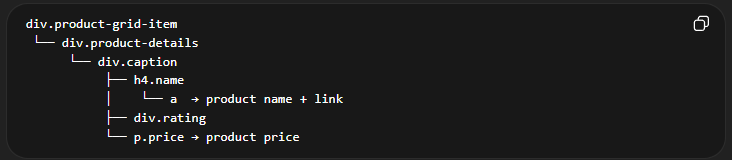




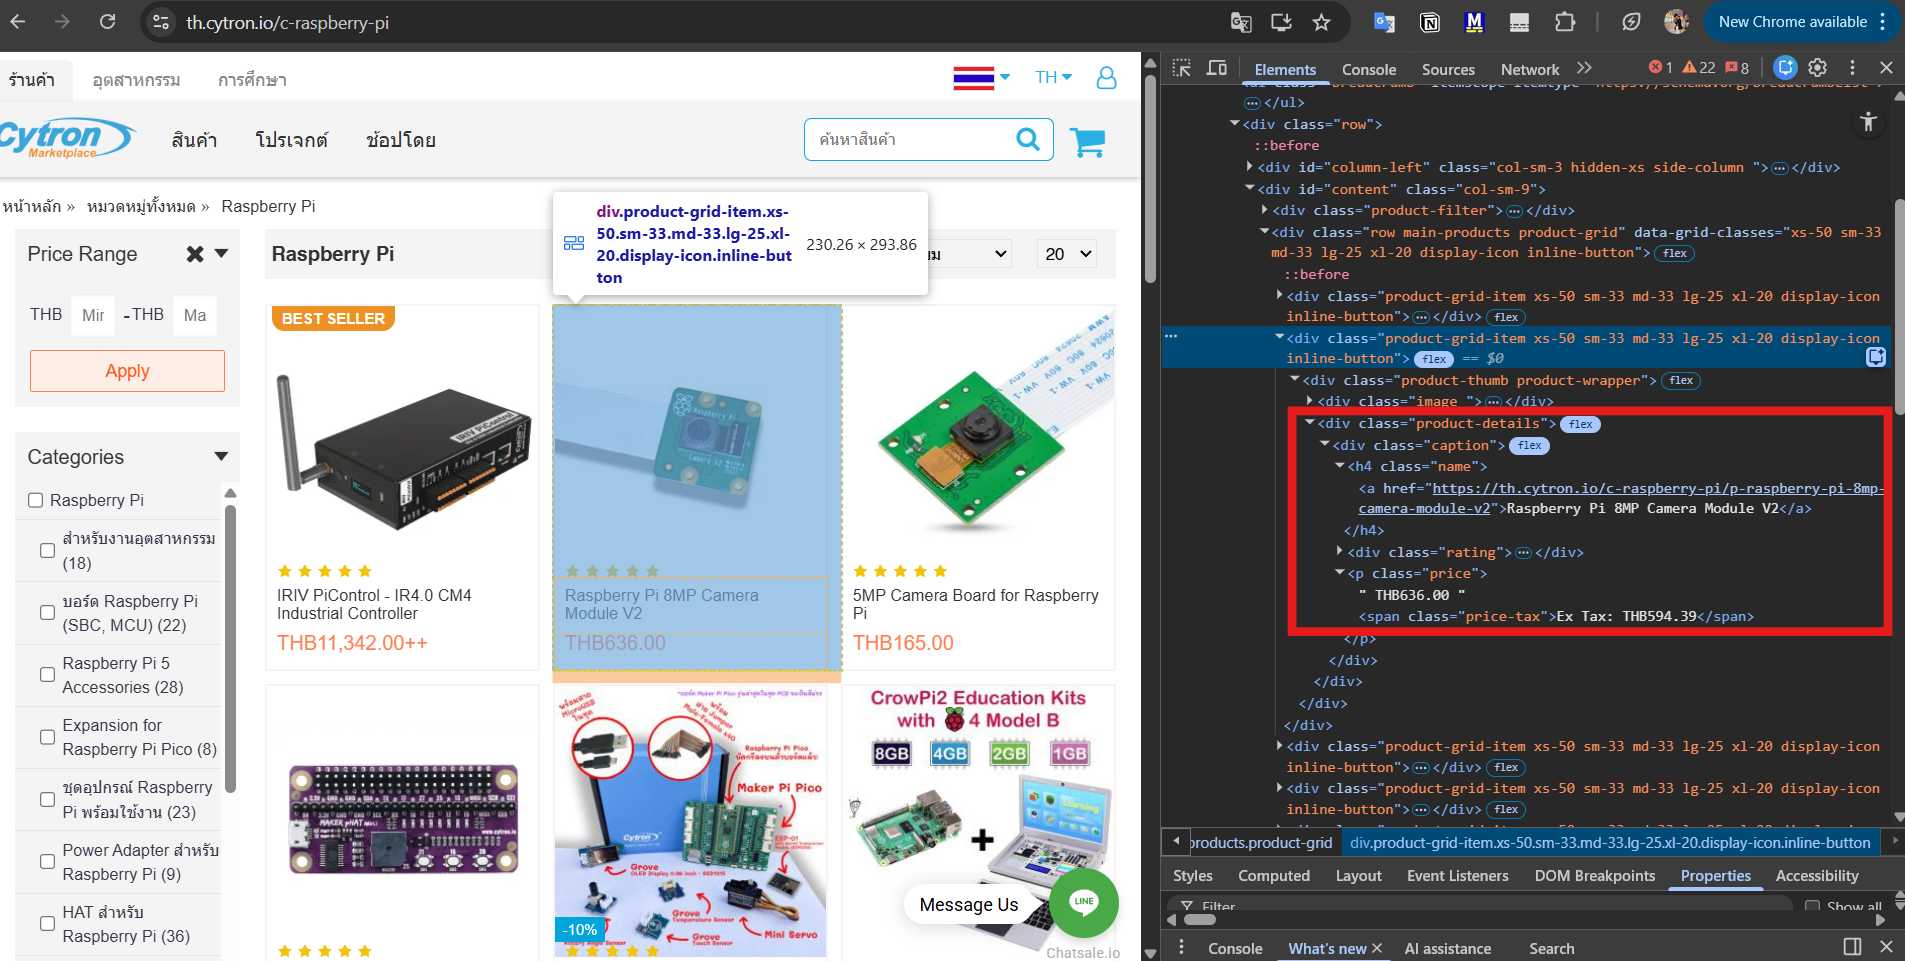

In [ ]:

from gazpacho import Soup
import requests
import pandas as pd

## Step 1: Get HTML from website
url = "https://th.cytron.io/c-raspberry-pi"  # replace with real site

# Adding a user-agent is often necessary for this site to avoid being blocked
headers = {'User-Agent': 'Mozilla/5.0'}
response = requests.get(url, headers=headers)

## Step 2: Parse HTML
soup = Soup(response.text)

## Step 3: Find all product blocks
products = soup.find("div", {"class": "product-grid-item"}, mode="all") # ✅ Use mode="all" to get a list of all product containers

# Safety check
if not products:
    raise ValueError("No products found — likely wrong selector or JS-loaded page")

## Step 4: Extract data
data = []

for item in products:
    # gazpacho's .find() on an item returns the inner content/tags
    # Name: finding the 'a' tag inside 'h4.name' as per your image
    name_tag = item.find("h4", {"class": "name"})
    # name_tag.text gets the text content directly
    name = name_tag.text if name_tag else None

    # Price
    price_tag = item.find("p", {"class": "price"})
    price = price_tag.text if price_tag else None

    data.append({
        "Product Name": name,
        "Price": price
    })

## Step 5: Convert to DataFrame
df = pd.DataFrame(data)
# Clean up whitespace if necessary
df['Product Name'] = df['Product Name'].str.strip()
df['Price'] = df['Price'].str.strip()


display(df)

,Product Name,Price
0,IRIV PiControl - IR4.0 CM4 Industrial Controller,"THB11,342.00++"
1,Raspberry Pi 8MP Camera Module V2,THB636.00
2,5MP Camera Board for Raspberry Pi,THB165.00
3,Maker pHAT: Simplifying Raspberry Pi for {Educ...,THB360.00
4,ชุดการเรียนรู้ Raspberry Pi Pico,"THB1,179.90"
5,CrowPi2 and Raspberry Pi 4 Model B Education Kits,"THB13,458.28++"
6,Raspberry Pi 4B Beginner Kit-w/o RPi and Adapter,"THB1,160.00"
7,Raspberry Pi A2 microSD - พร้อมระบบปฏิบัติการ ...,THB780.00++
8,Official Raspberry Pi 4 Model B 8GB และชุดอุปกรณ์,"THB4,134.00++"
9,Official การ์ด MakerDisk microSD พร้อมระบบปฏิบ...,THB700.00++


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1V6qCvX5NFvwhSWTcMQOq42uTBtLsBZiXdI2tVfNikoM/edit#gid=0


### Shopee

In [ ]:
from gazpacho import Soup
import requests
import pandas as pd

# Step 1: Get HTML from website
url = "https://shopee.co.th/search?keyword=powerbank"  # replace with real site
response = requests.get(url)

# Step 2: Parse HTML
soup = Soup(response.text)

# Step 3: Find all product blocks
products = soup.find("div", {"class": "space-y-1 mb-1 flex-1 flex flex-col justify-between min-h-[4rem] my:min-h-[5rem] km:min-h-[5rem]"})
print(products)
# Step 4: Extract data
data = []

for item in products:
    name = item.find("div", {"class": "whitespace-normal line-clamp-2 break-words min-w-0 min-h-[2.5rem] text-sm th:text-[12px] my:text-[12px] km:text-[12px]"}).text
    price = item.find("span", {"class": "truncate text-base/5 font-medium"}).text

    data.append({
        "Product Name": name,
        "Price": price
    })

# Step 5: Convert to DataFrame
df = pd.DataFrame(data)

print(df.head())

# Others

In [ ]:
# from gazpacho import get, Soup

# url = 'https://scrape.world/books'
# html = get(url)
# soup = Soup(html)
# books = soup.find('div', {'class': 'book-'}, partial=True)

# def parse(book):
#     name = book.find('h4').text
#     price = float(book.find('p').text[1:].split(' ')[0])
#     return name, price

# [parse(book) for book in books]

In [ ]:
# # find the element you want - h1
# web.find("h1")

# # find the element you want - h2
# web.find("h2")

# # find the element you want - h3
# web.find("h3")